# Analysis of duration of information transfer relationships

**Notebook contents:**
* Extract persistence of leader follower relationships from data
* Plot visualizations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import utils
from utils import set_plot_style

# Preliminaries

In [ ]:
phenotype_dict = {
    'singlemill':[0.5,0.1],
    'doublemill':[0.9,0.5],
    'doublering':[0.5,0.5],
    'collswarm':[0.5,0.9],
    'escapesymm':[2,0.9],
    'escapeunsymm':[2,2],
    'escapecoll':[2,3]
    }

legend_labels = utils.proper_phenotype_names

dorsogna_TE_exports_dir = 'csvs_actual_te_values'
graphs_dict = 'graphs'

In [ ]:
# storing linear velocity-based TE dataframes
TEdf_dict_linvel = {}
for phenotype in phenotype_dict.keys():
    filename = f"{dorsogna_TE_exports_dir}/{phenotype}/TElog_{phenotype}_{phenotype_dict[phenotype][0]}_{phenotype_dict[phenotype][1]}_linvel_k15.csv"
    TE_df = pd.read_csv(filename, index_col = 0)
    TEdf_dict_linvel[phenotype] = TE_df

In [ ]:
# storing angular velocity-based TE dataframes
TEdf_dict_angvel = {}
for phenotype in phenotype_dict.keys():
    filename = f"{dorsogna_TE_exports_dir}/{phenotype}/TElog_{phenotype}_{phenotype_dict[phenotype][0]}_{phenotype_dict[phenotype][1]}_angvel_k15.csv"
    TE_df = pd.read_csv(filename, index_col = 0)
    TEdf_dict_angvel[phenotype] = TE_df

# Persistence of TE relationships

In [ ]:
def get_all_persistence_streaks(df):
    # convert to boolean mask (True if TE > 0)
    mask = (df.values != 0).astype(int)
    all_streaks = []
    pair_max_persistence = {}

    # iterate through columns (pairs)
    for i, col_name in enumerate(df.columns):
        # find where values change (0 to 1 or 1 to 0)
        padded = np.diff(np.concatenate(([0], mask[:, i], [0])))
        starts = np.where(padded == 1)[0]
        ends = np.where(padded == -1)[0]
        streaks = ends - starts
        
        if len(streaks) > 0:
            all_streaks.extend(streaks)
            pair_max_persistence[col_name] = streaks.max()
        else:
            pair_max_persistence[col_name] = 0
            
    return np.array(all_streaks), pd.Series(pair_max_persistence)

In [ ]:
persistence_dict_linvel = {}

for phenotype, df in TEdf_dict_linvel.items():
    streaks, max_per_pair = get_all_persistence_streaks(df)
    streaks = streaks/10
    persistence_dict_linvel[phenotype] = [streaks, max_per_pair]

    stats = {
        "Total Active Events": len(streaks),
        "Average Persistence": np.mean(streaks),
        "Median Persistence": np.median(streaks),
        "Max Persistence (Single Event)": np.max(streaks),
        "Std Dev": np.std(streaks)
    }
    print('\n')
    print(phenotype + ' ' + '='*50)
    print(pd.Series(stats))


persistence_dict_angvel = {}

for phenotype, df in TEdf_dict_angvel.items():
    streaks, max_per_pair = get_all_persistence_streaks(df)
    streaks = streaks/10
    persistence_dict_angvel[phenotype] = [streaks, max_per_pair]

    stats = {
        "Total Active Events": len(streaks),
        "Average Persistence": np.mean(streaks),
        "Median Persistence": np.median(streaks),
        "Max Persistence (Single Event)": np.max(streaks),
        "Std Dev": np.std(streaks)
    }
    print('\n')
    print(phenotype + ' ' + '='*50)
    print(pd.Series(stats))

# Plotting

In [ ]:
streaks_collection_linvel = []
for phenotype, value in persistence_dict_linvel.items():
    streaks, max_per_pair = value
    streaks_collection_linvel.append(streaks)

streaks_collection_angvel = []
for phenotype, value in persistence_dict_angvel.items():
    streaks, max_per_pair = value
    streaks_collection_angvel.append(streaks)

## Linear velocity

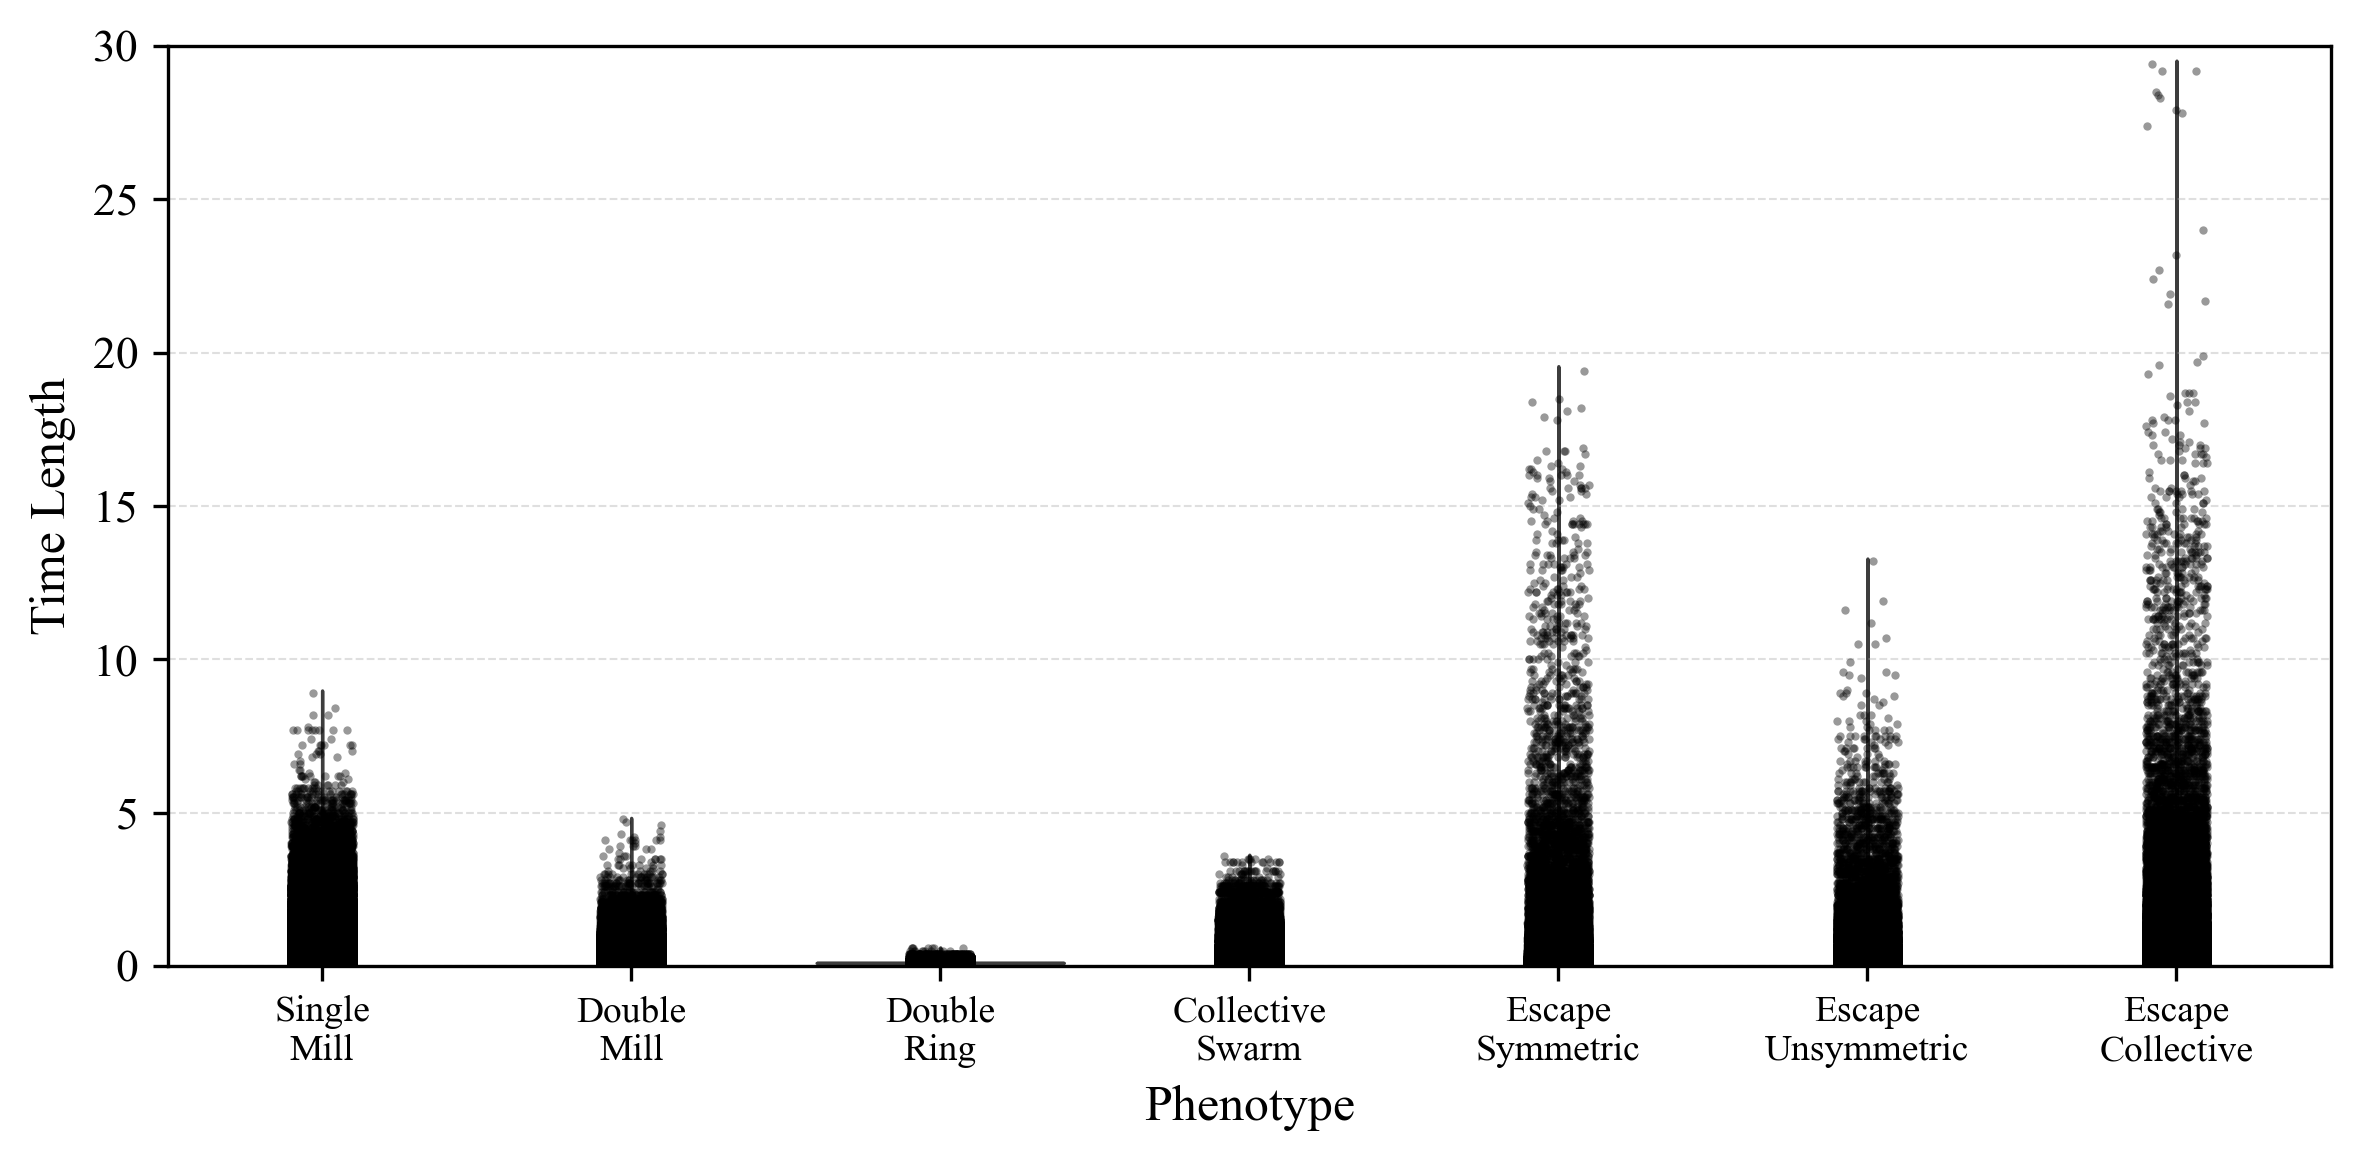

In [ ]:
set_plot_style()

fig, ax = plt.subplots(figsize=(8, 4))

sns.violinplot(
    data=streaks_collection_linvel,
    ax=ax,
    color="lightgrey",
    linewidth=0.8,
    inner=None,
)

sns.stripplot(
    data=streaks_collection_linvel,
    ax=ax,
    color="black",
    size=2,
    alpha=0.4,
    jitter=True,
)

# zero line
ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")

# axis labels
ax.set_xlabel("Phenotype")
ax.set_ylabel("Time Length")

# x-tick labels
ax.set_xticks(range(len(phenotype_dict)))
ax.set_xticklabels([label.replace(" ", "\n") for label in legend_labels.values()], rotation=0, ha="center", fontsize=9)
ax.set_ylim(0,30)
ax.grid(axis="y")

plt.tight_layout()

# save
folder_name = f"{graphs_dict}/persistence"
file_name = "streaks_violin_linvel.png"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"folder {folder_name} created")

save_path = os.path.join(folder_name, file_name)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

## Angular velocity

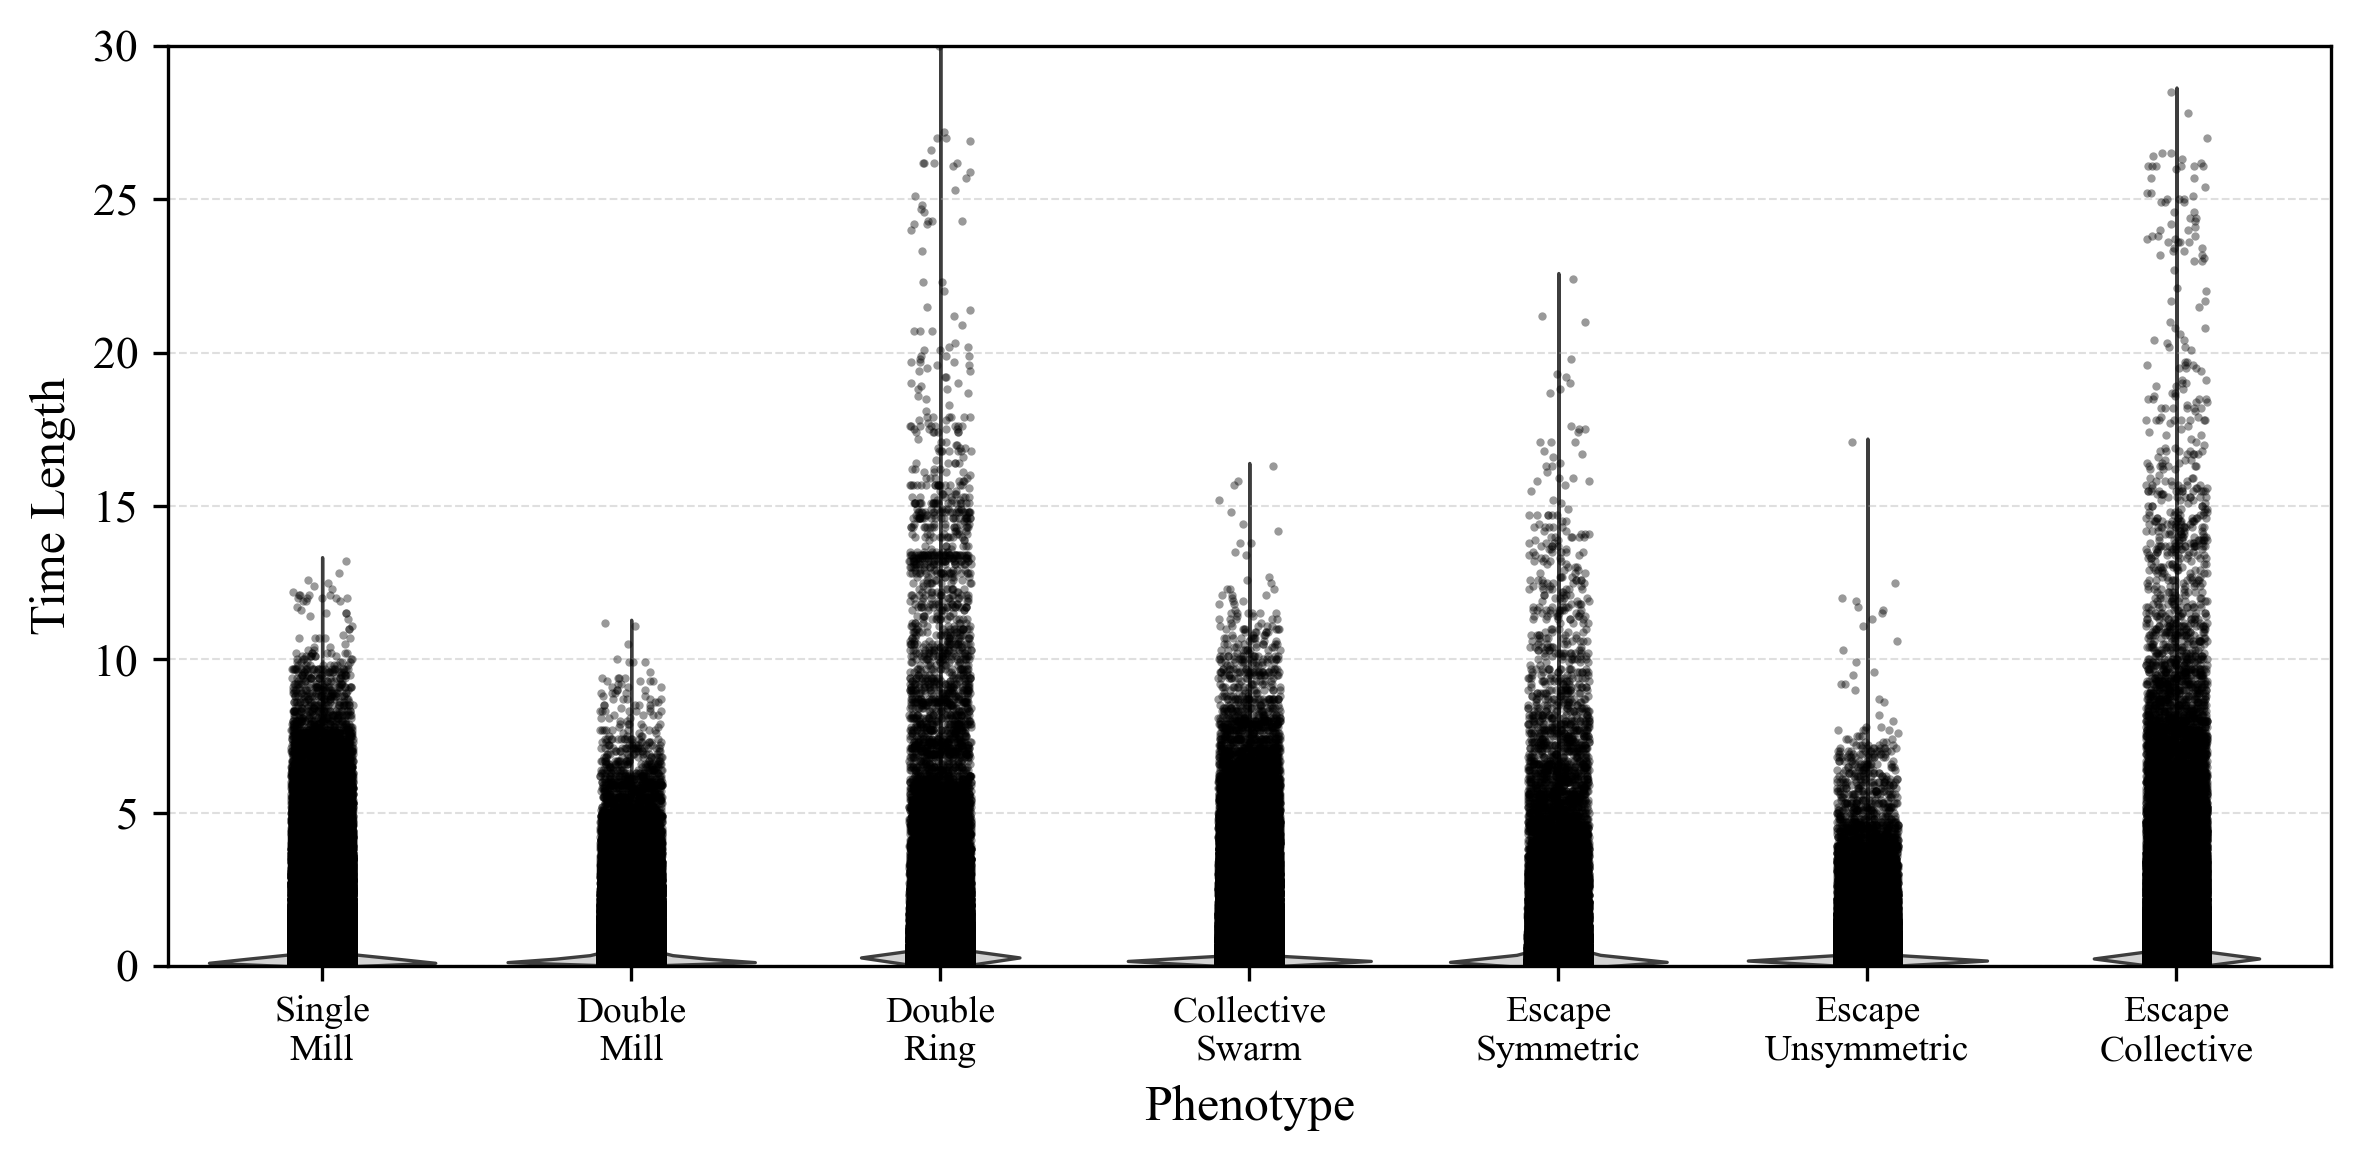

In [ ]:
set_plot_style()

fig, ax = plt.subplots(figsize=(8, 4))

sns.violinplot(
    data=streaks_collection_angvel,
    ax=ax,
    color="lightgrey",
    linewidth=0.8,
    inner=None,
)

sns.stripplot(
    data=streaks_collection_angvel,
    ax=ax,
    color="black",
    size=2,
    alpha=0.4,
    jitter=True,
)

# zero line
ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")

# axis labels
ax.set_xlabel("Phenotype")
ax.set_ylabel("Time Length")

# x-tick labels
ax.set_xticks(range(len(phenotype_dict)))
ax.set_xticklabels([label.replace(" ", "\n") for label in legend_labels.values()], rotation=0, ha="center", fontsize=9)
ax.set_ylim(0,30)
ax.grid(axis="y")

plt.tight_layout()

# save
folder_name = f"{graphs_dict}/persistence"
file_name = "streaks_violin_angvel.png"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"folder {folder_name} created")

save_path = os.path.join(folder_name, file_name)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()